In [187]:
import pandas as pd
import numpy as np
from time import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.base import clone
from sklearn.linear_model import SGDRegressor, SGDClassifier
from sklearn.metrics import log_loss


RANDOM_SEED = 0

In [188]:
data = pd.read_csv("https://raw.githubusercontent.com/ProfAI/machine-learning-modelli-e-algoritmi/refs/heads/main/datasets/breast_cancer.csv")

In [189]:
# create copy not to alter original data
dataSet = data.copy()

# drop id column
dataSet = dataSet.drop(dataSet.columns[0], axis=1)

# Map target values to numeric values
dataSet["diagnosis"] = dataSet["diagnosis"].map({"M": 1, "B": 0}).values

# extract features and target
X = dataSet.drop("diagnosis", axis = 1).values
y = dataSet["diagnosis"].values

In [190]:
# split dataset for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = RANDOM_SEED)

In [191]:
# scale our data
ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [192]:
def mini_batch_gd(model, train_data, test_data, epochs, size, n_batches):
    tick = time()
    X_train, y_train = train_data

    classes = np.unique(y_train)
    for epoch in range(epochs):
        X_shuffled, y_shuffled = shuffle(X_train, y_train)

        for batch in range(n_batches):
            batch_start = int(batch * size)
            batch_end = int((batch + 1) * size)
            X_batch = X_shuffled[batch_start: batch_end, :]
            y_batch = y_shuffled[batch_start: batch_end]

            if epoch == 0 and batch == 0:
                model.partial_fit(X_batch, y_batch, classes=classes)
            else:
                model.partial_fit(X_batch, y_batch)

    duration = time() - tick

    print(f"MiniBatchGD for batch size of {size} ended in {duration:.2f} seconds")

    return model, duration


In [193]:
def find_best_batch_size(base_model, train_data, test_data, batch_sizes = [8, 16, 32, 64, 128] , epochs = 5):
    results = []
    X_train, y_train = train_data
    X_test, y_test = test_data
    best_score = float("inf")
    best_model = None

    for size in batch_sizes:
        n_batches = int(np.ceil(X_train.shape[0] / size))
        model = clone(base_model)
        model, duration = mini_batch_gd(model, train_data, test_data, epochs, size, n_batches)

        if hasattr(model, "predict_proba"):
            y_pred = model.predict_proba(X_test)
        else:
            y_pred = model.predict(X_test)

        score = log_loss(y_test, y_pred)
        results.append({"batch_size": size, "score": score, "duration": duration})
        if score < best_score:
            best_score = score
            best_model = model

    if best_model is None:
        return None

    return best_model, best_score, results


In [194]:
def display_results(results):
    results_df = pd.DataFrame(results).sort_values("score")
    best = results_df.iloc[0]
    print(f"✅ Miglior batch size: {int(best['batch_size'])} → {'score'} = {best['score']:.4f}, tempo {best['duration']:.2f}s")

    # Visualizzazione
    display(results_df)
    fig, ax = plt.subplots()
    ax.plot(results_df['batch_size'], results_df['score'], marker='o')
    ax.set_xscale('log', base=2)
    ax.set_xlabel('batch size')
    ax.set_ylabel('score (più basso è meglio)')
    ax.set_title('Batch size vs score')
    plt.show()

MiniBatchGD for batch size of 8 ended in 0.10 seconds
MiniBatchGD for batch size of 16 ended in 0.02 seconds
MiniBatchGD for batch size of 32 ended in 0.01 seconds
MiniBatchGD for batch size of 64 ended in 0.01 seconds
MiniBatchGD for batch size of 128 ended in 0.00 seconds
✅ Miglior batch size: 128 → score = 0.0188, tempo 0.00s


,batch_size,score,duration
4,128,0.018826,0.004154
3,64,0.276643,0.005988
0,8,0.320964,0.095139
2,32,0.577398,0.009923
1,16,0.971273,0.018091


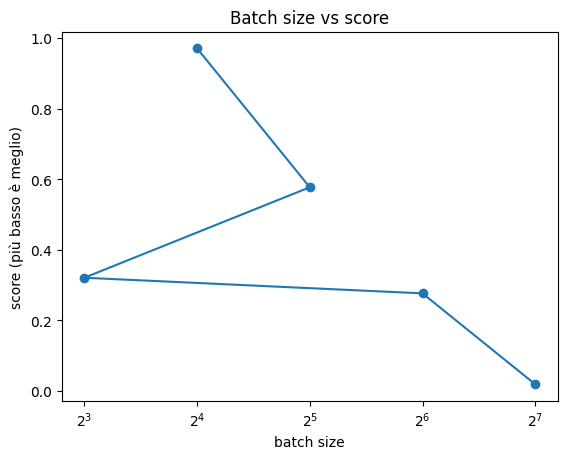

In [196]:
# let's now create and train a model using Mini Batch GD
model = SGDClassifier(loss="log_loss")

batch_sizes = [8, 16, 32, 64, 128]
epochs = 5
best_model, best_score, results = find_best_batch_size(model, (X_train, y_train), (X_test, y_test), batch_sizes, epochs)
display_results(results)